# Art as Data

Piet Mondrian was a Dutch artist best known for his abstract, grid-like designs during the 1920s and 30s. Mondrian was part of an art movement that aimed to explore and express simplicity by using only the most basic colors and shapes.

How might we represent the features of a Mondrian painting using tabular data? Here is one approach:

| painting_id | feature | x   | y   | width | height | color  | rgb      |
|------------|---------|-----|-----|-------|--------|--------|----------|
| b219       | rect    | 0   | 0   | 121   | 152    | white  | #ffffff  |
| b219       | rect    | 132 | 0   | 378   | 365    | red    | #e6151a  |
| b219       | rect    | 0   | 173 | 121   | 192    | white  | #ffffff  |
| b219       | rect    | 0   | 377 | 121   | 133    | blue   | #2f5a9f  |
| b219       | rect    | 132 | 377 | 335   | 133    | white  | #ffffff  |
| b219       | rect    | 479 | 377 | 31    | 59     | white  | #ffffff  |
| b219       | rect    | 479 | 451 | 31    | 59     | yellow | #f7ed2d  |
| b219       | h-line  | 0   | 365 | 510   | 12     | black  | #000000  |
| b219       | v-line  | 121 | 0   | 11    | 510    | black  | #000000  |
| b219       | v-line  | 467 | 377 | 12    | 133    | black  | #000000  |
| b219       | h-line  | 0   | 152 | 121   | 21     | black  | #000000  |
| b219       | h-line  | 479 | 436 | 31    | 15     | black  | #000000  |

This table represents the features of the painting using 12 rows of data. Notice how each row represents a rectangular shape with x-y coordinates, size and color info.

By representing art as data, we open up artistic analysis to a broad range of data science techniques. In this project, we will explore Mondrian's quest for artistic simplicity and try our hands at detecting fake paintings falsely attributed to Mondrian.

### Loading the Data
The `mondrian-painting-features.csv` file contains digitized features for 136 Mondrian paintings over the 2 decades from 1920 to 1940.


In [115]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


In [116]:
pd.options.display.max_rows = 10 

features = pd.read_csv('mondrian-painting-features.csv')
features 

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
3199,b296,v-line,620,0,19,825,black,#000000
3200,b296,v-line,49,508,19,79,black,#000000
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000


The first painting in this dataset has an ID of b104. We can see that there are multiple rows with that same painting ID.

Let's extract all the features associated with that first painting.


In [117]:
features.query('painting_id == "b104"')

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
36,b104,v-line,727,0,5,1007,black,#000000
37,b104,v-line,258,18,5,111,black,#000000
38,b104,v-line,531,134,5,809,black,#000000
39,b104,v-line,944,134,5,873,black,#000000


From this we see that painting b104 has 41 features.

We have got the features for this painting, but what if we are interested in the year it was painted?

For that, we need to load up a separate data file: `mondrian-painting-info.csv`.


In [118]:
painting_info = pd.read_csv('mondrian-painting-info.csv')
painting_info

,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
3,b107,1920,Composition C,610,603
4,b108,1920,Composition I,646,750
...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052
132,b293,1939,"Composition of red, blue and white: II",330,435
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752


Each row represents one painting. Now we see that b104 was painted in the year 1920. Later, when we calculate painting metrics, we'll merge additional columns onto this `painting_info` dataframe.

### Turning Data into Pictures


In [119]:

def draw_mondrian( painting_id ):
    rects = features.query('painting_id == @painting_id')
    total_width = rects.eval("x + width").max()
    total_height = rects.eval("y + height").max()
    
    fig, ax = plt.subplots(figsize=(3, 3))
    
    for (idx, row) in rects.iterrows():
        x, y, w, h, rgb = row[['x','y','width','height','rgb']]
        patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
        ax.add_patch(patch)
    
    ax.axis([0, total_width, 0, total_height])
    ax.set_aspect('equal')
    ax.axis('off')
    fig.text(0.5, 0.01, painting_id, ha="center", fontsize=14)



We can run this function any time we want to visualize a painting. For example, let's see what the first painting in our dataset (b104) looks like.


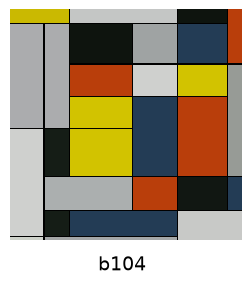

In [120]:
draw_mondrian('b104')


### Comparing Complexity

As mentioned earlier, Piet Mondrian was part of a movement to simplify artistic expression. Do Mondrian paintings vary substantially in their simplicity?



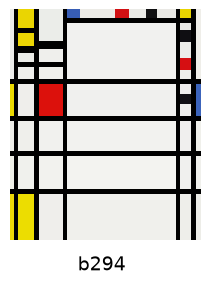

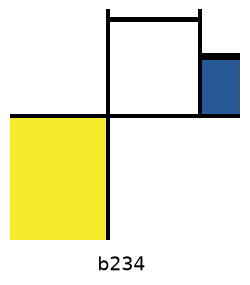

In [121]:
draw_mondrian('b294')
draw_mondrian('b234')

The left painting is more complex due to having more horizontal lines, vertical lines, and rectangles.

### Quantifying Complexity
Art researchers have used a variety of approaches to quantify the complexity of Mondrian paintings. Perhaps the easiest method is to simply count the number of features in a given painting. Let's explore this basic metric and see if we encounter any interesting trends over time.


In [122]:
pd.options.display.max_rows = 6
features

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
...,...,...,...,...,...,...,...,...
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000
3203,b296,h-line,0,679,11,28,black,#000000


In [123]:
pd.options.display.max_rows = 10
sizes = features.groupby('painting_id').size()
sizes


painting_id
b104    41
b105    42
b106    41
b107    44
b108    44
        ..
b292    31
b293    26
b294    62
b295    47
b296    49
Length: 136, dtype: int64

This gives us the number of features for all 136 paintings. The output above is a 1-dimensional series where the index is the `painting_id`.



In [124]:
complexity_df = sizes.reset_index(name='complexity')
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
3,b107,44
4,b108,44
...,...,...
131,b292,31
132,b293,26
133,b294,62
134,b295,47


This gives us a dataframe with the complexity (number of features) for each painting ID. We now have complexity data for all 136 paintings.

### Merging Data
We want to plot complexity over time, but currently we have complexity in one dataframe and the year in a different dataframe.

In [125]:
pd.options.display.max_rows = 6
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
...,...,...
133,b294,62
134,b295,47
135,b296,49


In [126]:
painting_info


,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
...,...,...,...,...,...
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752
135,b296,1940,Composition no. 11,711,825


Let's add the complexity data into the `painting_info` dataframe. This will allow us to plot how complexity changes by year.



In [127]:
pd.options.display.max_rows = 10
painting_info = painting_info.merge(complexity_df, on='painting_id', how='left')
painting_info

,painting_id,year,title,width,height,complexity
0,b104,1920,No. VI,1010,1007,41
1,b105,1920,Composition A,918,900,42
2,b106,1920,Composition B,575,677,41
3,b107,1920,Composition C,610,603,44
4,b108,1920,Composition I,646,750,44
...,...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052,31
132,b293,1939,"Composition of red, blue and white: II",330,435,26
133,b294,1939,Trafalgar Square,1200,1452,62
134,b295,1939,Composition no. 8,681,752,47


We have now merged the `complexity_df` into `painting_info`.

### Plotting Complexity over Time

Let's visualize how complexity changes over the years for these Mondrian paintings. A scatterplot would work well for this.


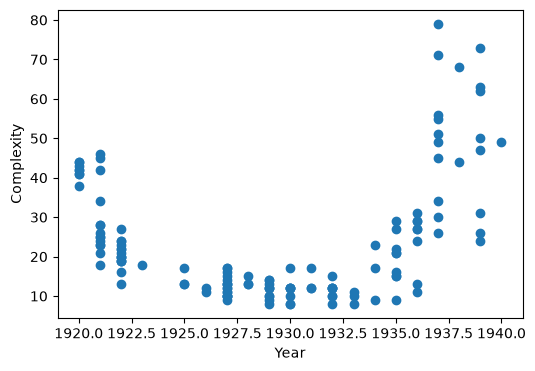

In [128]:
plt.figure(figsize=(6, 4))
plt.scatter(painting_info['year'], painting_info['complexity'])
plt.xlabel('Year')
plt.ylabel('Complexity')
plt.show()

The complexity of Mondrian's paintings increases after 1935, indicating a shift in his artistic style.

### Detecting Possible Fake Paintings
Since Mondrian paintings can sell for millions of dollars, it's not hard to imagine that someone might try to create a forgery. The following is a widely shared painting claimed to be a Mondrian artwork from 1926.

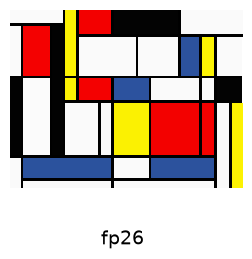

In [129]:
rects = pd.read_csv('fp26-features.csv')
total_width = rects.eval("x + width").max()
total_height = rects.eval("y + height").max()

fig, ax = plt.subplots(figsize=(3, 3))

for (idx, row) in rects.iterrows():
	x, y, w, h, rgb = row[['x','y','width','height','rgb']]
	patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
	ax.add_patch(patch)

ax.axis([0, total_width, 0, total_height])
ax.set_aspect('equal')
ax.axis('off')
fig.text(0.5, 0.01, 'fp26', ha="center", fontsize=14)
plt.show()


This painting doesn't show up in our catalog. Is it real or fake? Let's see what evidence we can glean from the data.

Load up the feature data for this painting from the file `fp26-features.csv`.


In [130]:
fp26_features = pd.read_csv('fp26-features.csv')
fp26_features 

,painting_id,feature,x,y,width,height,color,rgb
0,fp26,rect,0,0,34,92,white,#fafafa
1,fp26,rect,41,0,267,22,white,#f9f9f9
2,fp26,rect,317,0,309,22,white,#fafafa
3,fp26,rect,634,0,38,261,white,#fafafa
4,fp26,rect,680,0,32,261,yellow,#fcf202
...,...,...,...,...,...,...,...,...
49,fp26,h-line,206,462,506,8,black,#000000
50,fp26,h-line,0,497,166,8,black,#000000
51,fp26,v-line,270,96,9,169,black,#000000
52,fp26,v-line,580,96,7,370,black,#000000


Using our number of features metric for complexity, we can see that this painting has a complexity of 54.

Is a complexity of 54 consistent with other Mondrain paintings in the year 1926? Let's add this datapoint to our scatterplot for a visual comparison.


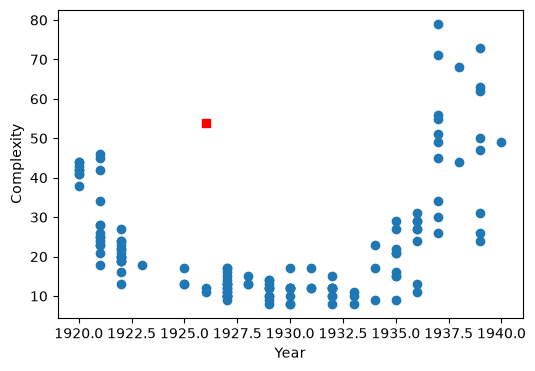

In [131]:
plt.figure(figsize=(6, 4))
plt.scatter(painting_info['year'], painting_info['complexity'])
plt.scatter(x=1926, y=54, color='red', marker='s')
plt.xlabel('Year')
plt.ylabel('Complexity')
plt.show()


The 1926 painting is an outlier with much higher complexity than other paintings from that period, suggesting it might be a fake.


## Project extensions


## Project Extension 1: Analyze painting dimensions over time


To understand how Mondrian's painting dimensions evolved, we'll calculate the area of each painting and then plot the width, height, and area against the year of creation. This will help us identify any trends in his preferred canvas sizes.

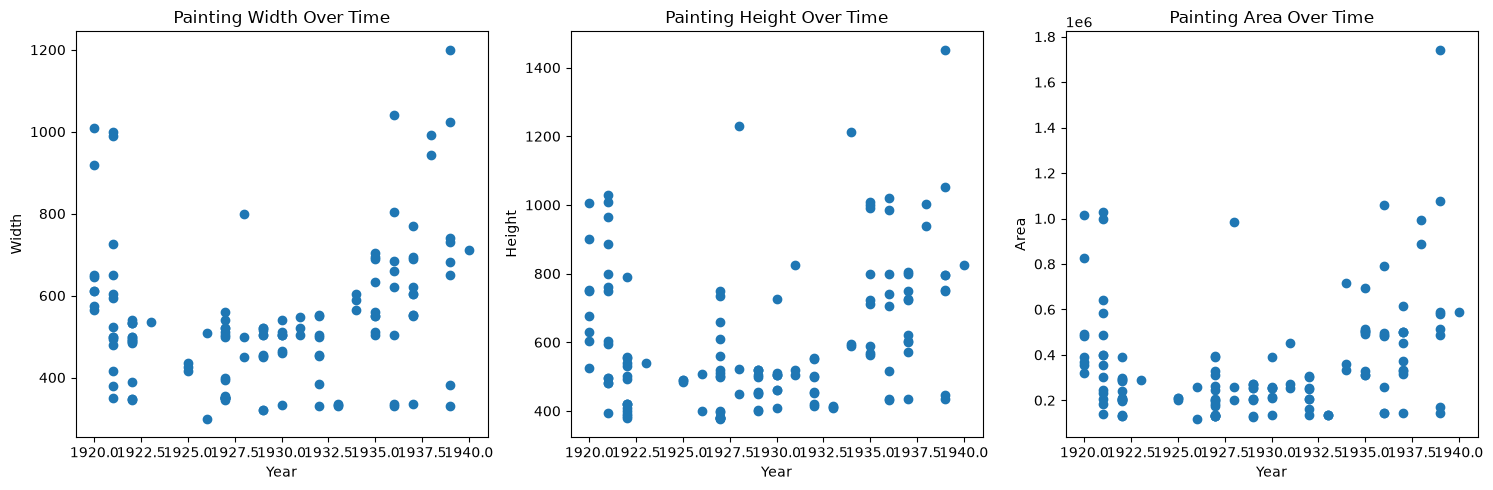

In [132]:
painting_info['area'] = painting_info['width'] * painting_info['height']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(painting_info['year'], painting_info['width'])
plt.xlabel('Year')
plt.ylabel('Width')
plt.title('Painting Width Over Time')

plt.subplot(1, 3, 2)
plt.scatter(painting_info['year'], painting_info['height'])
plt.xlabel('Year')
plt.ylabel('Height')
plt.title('Painting Height Over Time')

plt.subplot(1, 3, 3)
plt.scatter(painting_info['year'], painting_info['area'])
plt.xlabel('Year')
plt.ylabel('Area')
plt.title('Painting Area Over Time')

plt.tight_layout()
plt.show()


The plots above show how the width, height, and calculated area of Mondrian's paintings change over time. There isn't a strong, consistent trend of increasing or decreasing size over the period from 1920 to 1940. However, we can observe that there's a wider spread in dimensions in later years (post-1935), indicating a potential experimentation with a broader range of canvas sizes, or perhaps a higher number of larger works. For example, some very large paintings appear around 1939-1940, especially noticeable in the 'Painting Area Over Time' plot.

### Project Extension 2. Track color usage over time

Next, we'll analyze how the usage of different colors (blue, red, yellow, white, black, gray) in Mondrian's paintings evolved over time.

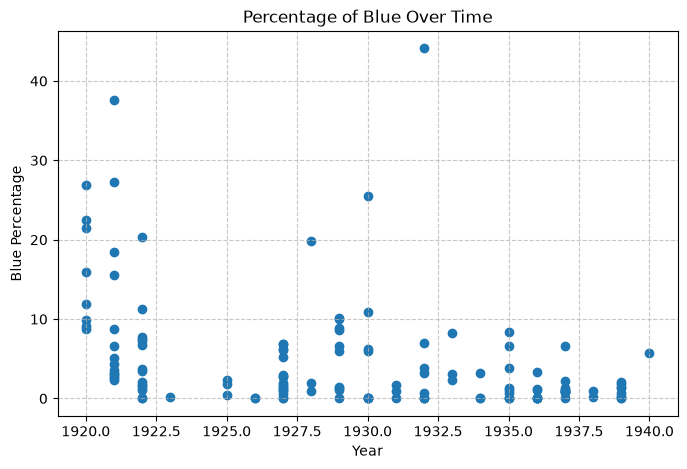

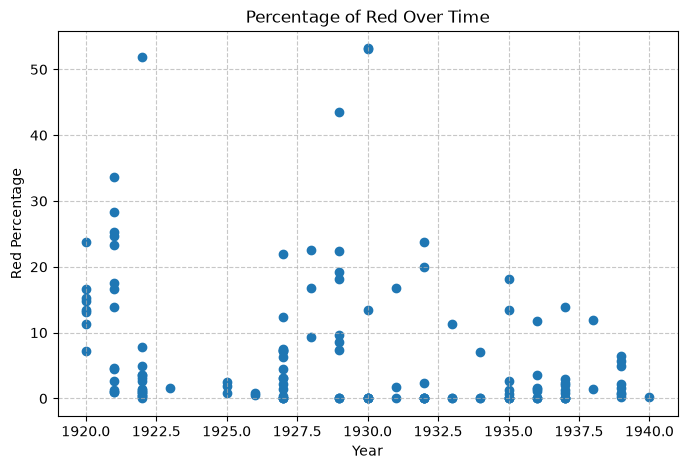

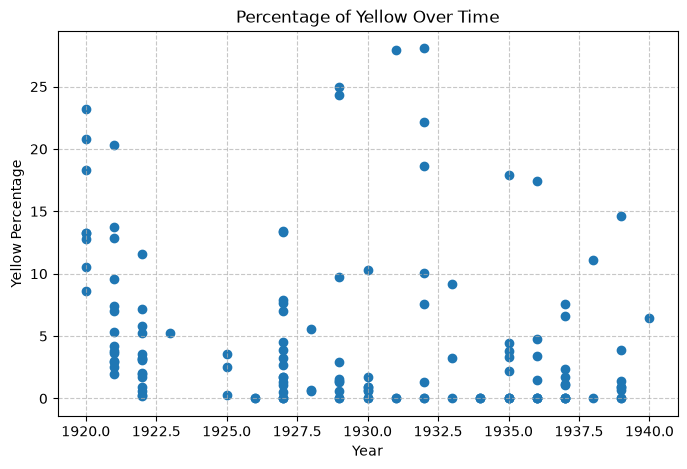

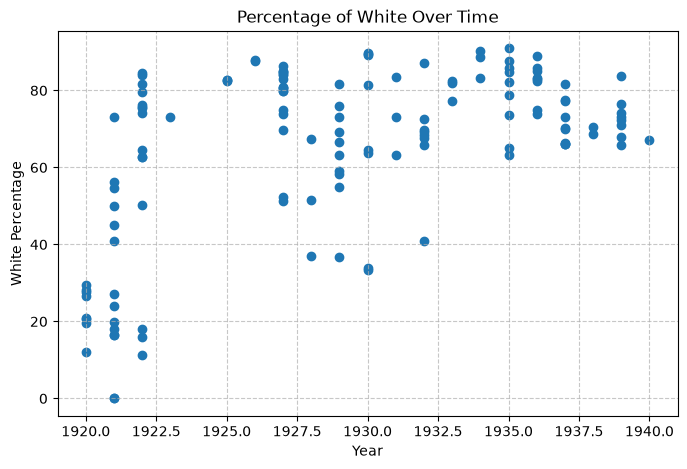

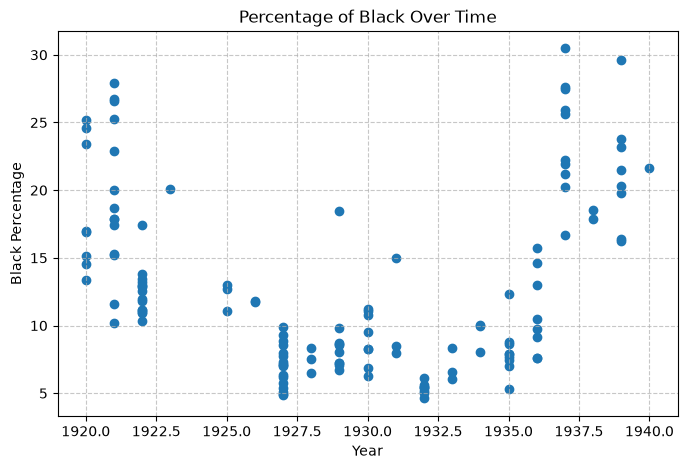

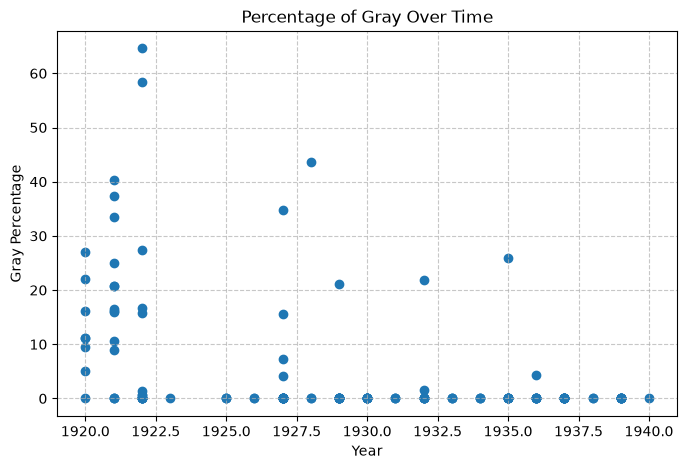

In [ ]:
features['feature_area'] = features['width'] * features['height']

def calculate_and_plot_color_percentage(color_name):

    color_features = features[features['color'] == color_name]

    color_area_per_painting = color_features.groupby('painting_id')['feature_area'].sum().reset_index()
    color_area_per_painting = color_area_per_painting.rename(columns={'feature_area': f'{color_name}_area'})

    merged_df = pd.merge(painting_info, color_area_per_painting, on='painting_id', how='left').fillna(0)

    merged_df[f'{color_name}_percentage'] = (merged_df[f'{color_name}_area'] / merged_df['area']) * 100

    plt.figure(figsize=(8, 5))
    plt.scatter(merged_df['year'], merged_df[f'{color_name}_percentage'])
    plt.xlabel('Year')
    plt.ylabel(f'{color_name.capitalize()} Percentage')
    plt.title(f'Percentage of {color_name.capitalize()} Over Time')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


colors_to_analyze = ['blue', 'red', 'yellow', 'white', 'black', 'gray']

for color in colors_to_analyze:
    calculate_and_plot_color_percentage(color)


The plots above illustrate the percentage of each primary color (blue, red, yellow, white, black, gray) used in Mondrian's paintings over the years. By analyzing these, we can observe potential shifts in his palette and emphasis:

*   **Blue, Red, Yellow**: These primary colors show varied usage, with some paintings having significant proportions while others have none. There isn't a clear increasing or decreasing trend, but rather a dynamic use, suggesting that the presence and intensity of these colors might be more about individual composition than a consistent evolutionary path.
*   **White**: White consistently occupies a large portion of most paintings, which is expected given Mondrian's style and use of negative space. Its percentage might fluctuate, but it remains a dominant color.
*   **Black**: Black, primarily used for lines, shows a relatively consistent presence, though its percentage area is generally much smaller than the background white or primary color blocks. Variations might indicate differences in line thickness or the density of the grid structure.
*   **Gray**: Gray is used less frequently and in smaller proportions compared to white and other colors, suggesting it was used for specific nuanced effects rather than as a foundational color.

Overall, Mondrian's reliance on primary colors and the stark contrast with white and black is evident throughout his career, though the specific distribution of the primary colors varied from piece to piece, contributing to the unique character of each work.

### Final Conclusion

This project analyzed Piet Mondrian's art through the lens of data science, treating painting features as tabular data. We started by loading and understanding two key datasets: `mondrian-painting-features.csv` and `mondrian-painting-info.csv`, which provided details about the geometric elements within each painting and the painting's metadata, respectively.

Key steps and findings include:

1.  **Data Loading and Inspection**: We successfully loaded the datasets and performed initial explorations to understand their structure and content.
2.  **Visualizing Art from Data**: A provided `draw_mondrian` function allowed us to reconstruct and visualize paintings directly from their feature data, demonstrating the power of representing art as data.
3.  **Quantifying Complexity**: We defined 'complexity' as the number of features in a painting. By grouping and counting features, we created a `complexity_df`. Merging this with `painting_info` enabled us to track complexity over time.
4.  **Complexity Over Time**: A scatterplot of complexity vs. year revealed that Mondrian's paintings showed an increase in complexity after 1935, suggesting a shift in his artistic approach during that period.
5.  **Detecting Potential Forgeries**: We applied our complexity analysis to a claimed 1926 Mondrian painting (`fp26`). Its complexity was significantly higher than other known works from the same year, strongly suggesting it might be a fake.
6.  **Analyzing Painting Dimensions**: We extended the analysis by calculating the area of each painting and plotting width, height, and area against the year. While no strong linear trend was observed, there was a wider spread in dimensions in later years, indicating greater variability in canvas size choices.
7.  **Tracking Color Usage**: We investigated the percentage of various colors (blue, red, yellow, white, black, gray) used in paintings over time. White consistently dominated, and black maintained a steady presence for lines. Primary colors (blue, red, yellow) showed dynamic, rather than strictly trending, usage, reflecting Mondrian's compositional choices for individual works.

Overall, this project showcased how data analysis techniques can provide quantitative insights into artistic styles and evolution, and even aid in art authentication. By converting visual art into structured data, we unlocked new avenues for understanding and interpreting complex artistic phenomena.